# 🏦 AI-Powered Credit Risk Scoring & Loan Decision System
## Intelligent Banking Decision Support Platform

> **Project Type:** Production-level Fintech AI System  
> **Scope:** End-to-end ML pipeline with Agentic AI and Customer Intelligence  
> **Dataset:** 4,269 real loan applications with 12 financial features  

---

### System Architecture Overview

```
┌─────────────────────────────────────────────────────────────────────┐
│                    BANKING DATA INGESTION LAYER                      │
│              (Loan Applications, Customer Profiles, CRB Data)        │
└──────────────────────────┬──────────────────────────────────────────┘
                           │
┌──────────────────────────▼──────────────────────────────────────────┐
│                    FEATURE ENGINEERING PIPELINE                       │
│   (Financial Ratios · Risk Indices · Affordability Scores · NLP)     │
└──────┬─────────────────────┬─────────────────────┬───────────────────┘
       │                     │                     │
┌──────▼──────┐    ┌─────────▼──────┐    ┌────────▼────────┐
│CLASSIFICATION│    │   REGRESSION   │    │   CLUSTERING    │
│Loan Approval│    │  Risk Score /  │    │ Customer Segment│
│Prediction   │    │  Loan Amount   │    │  (KMeans / DBSCAN)│
└──────┬──────┘    └─────────┬──────┘    └────────┬────────┘
       └─────────────────────┴─────────────────────┘
                             │
┌────────────────────────────▼────────────────────────────────────────┐
│                        AGENTIC AI LAYER                              │
│  Agent 1: Segmentation  │  Agent 2: Decision  │  Agent 3: Marketing │
└────────────────────────────┬────────────────────────────────────────┘
                             │
┌────────────────────────────▼────────────────────────────────────────┐
│              INTERACTIVE BUSINESS DASHBOARD (Streamlit)              │
│   Risk Scores · Approval Decisions · Campaigns · SHAP Explanations  │
└─────────────────────────────────────────────────────────────────────┘
```

---

### Business Value & Stakeholders

| Stakeholder | How the system helps |
|-------------|---------------------|
| **Loan Officers** | Automated first-pass decision with probability score and explanation |
| **Risk Analysts** | SHAP-based feature attribution, model drift monitoring |
| **Marketing Teams** | AI-generated personalized campaigns per customer segment |
| **Bank Management** | Portfolio-level risk dashboards, segment distribution KPIs |
| **Customers** | Faster decisions (seconds vs. days), transparent rejection reasons |

**Real-world deployment scenario:** A customer submits a loan application online. Within 2 seconds, Agent 2 (Decision Agent) runs the classification + regression models, Agent 1 assigns a customer segment, and Agent 3 generates a personalized counter-offer or campaign. A risk analyst reviews edge cases flagged by low confidence scores. Loan officers handle only manual exceptions.


## Section 1 — Environment Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              r2_score, mean_absolute_error, mean_squared_error,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

# Optional (install if available in your env)
try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — using GradientBoostingClassifier as substitute")

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = ['#185FA5', '#0F6E56', '#D85A30', '#BA7517', '#993556']
print("All imports successful.")

XGBoost available
All imports successful.


## Section 2 — Data Understanding & Quality Audit

### Dataset: 4,269 Loan Applications | 12 Features | 0 Missing Values

**Key data characteristics identified:**
- **Class imbalance:** 62.2% Approved vs 37.8% Rejected — mild, but requires stratified splits
- **CIBIL score range:** 300–900 (full bureau range) — the single most predictive feature
- **Negative residential asset value** found in data (min = -100,000) — likely a data entry error in source system; cap at 0 during cleaning
- **No leakage risk** from features — all inputs are available at application time
- **Scale heterogeneity:** Income in millions (up to 9.9M) vs. dependents (0–5) — StandardScaler essential


In [3]:
df_raw = pd.read_csv("loan_approval_dataset.csv")
df_raw.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("loan_approval_dataset.csv")

# ── Clean column names & string values immediately ────────────────────────────
df_raw.columns = df_raw.columns.str.strip()
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].str.strip()

print(f"Shape: {df_raw.shape}")
print(f"Null values: {df_raw.isnull().sum().sum()}")
print(f"Loan status distribution:")
print(df_raw['loan_status'].value_counts())
print()
print("Negative asset values (data quality flag):")
neg = (df_raw[['residential_assets_value','commercial_assets_value',
               'luxury_assets_value','bank_asset_value']] < 0).sum()
print(neg[neg > 0])
df_raw.describe().round(0)

Shape: (4269, 13)
Null values: 0
Loan status distribution:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Negative asset values (data quality flag):
residential_assets_value    28
dtype: int64


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.0,4269.0,4269.0,4269.0,4269.0,4269.0,4269.0,4269.0,4269.0,4269.0
mean,2135.0,2.0,5059124.0,15133450.0,11.0,600.0,7472617.0,4973155.0,15126306.0,4976692.0
std,1232.0,2.0,2806840.0,9043363.0,6.0,172.0,6503637.0,4388966.0,9103754.0,3250185.0
min,1.0,0.0,200000.0,300000.0,2.0,300.0,-100000.0,0.0,300000.0,0.0
25%,1068.0,1.0,2700000.0,7700000.0,6.0,453.0,2200000.0,1300000.0,7500000.0,2300000.0
50%,2135.0,3.0,5100000.0,14500000.0,10.0,600.0,5600000.0,3700000.0,14600000.0,4600000.0
75%,3202.0,4.0,7500000.0,21500000.0,16.0,748.0,11300000.0,7600000.0,21700000.0,7100000.0
max,4269.0,5.0,9900000.0,39500000.0,20.0,900.0,29100000.0,19400000.0,39200000.0,14700000.0


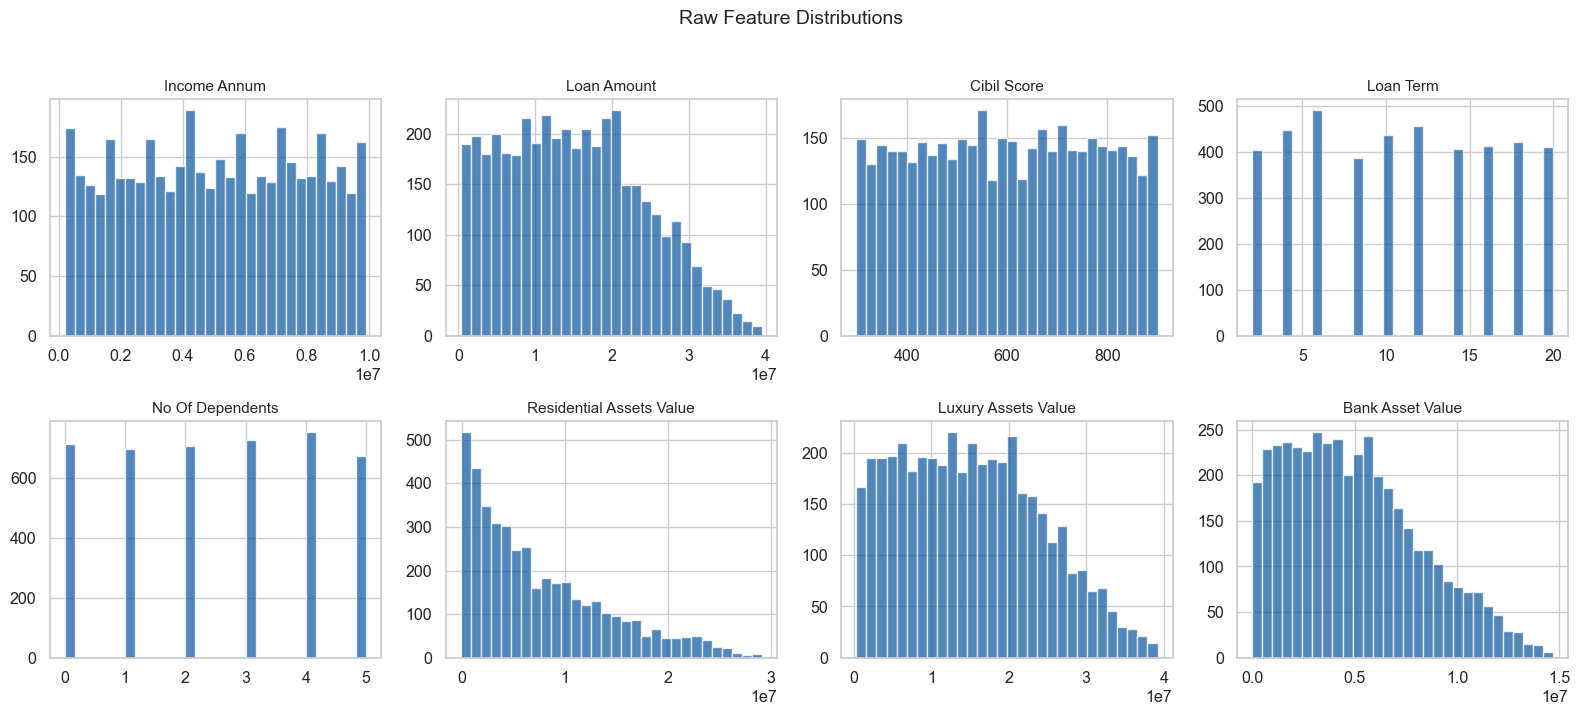

In [5]:
# ── Visualize raw distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

num_cols = ['income_annum', 'loan_amount', 'cibil_score', 'loan_term',
            'no_of_dependents', 'residential_assets_value',
            'luxury_assets_value', 'bank_asset_value']

for i, col in enumerate(num_cols):
    axes[i].hist(df_raw[col], bins=30, color=PALETTE[0], alpha=0.75, edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Raw Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Section 3 — Data Preprocessing

### Encoding strategy
Binary mapping by column name — explicit, readable, immune to column reordering.  
`OrdinalEncoder` with unnamed positional indexing (`iloc[:,2]`) is fragile and unreadable.

### Asset floor
Negative asset values are replaced with 0. In a production system this would trigger a data quality alert back to the originating branch.


In [6]:
df = df_raw.copy()

# Drop identifier
df.drop(columns=['loan_id'], inplace=True)

# Binary encoding — explicit mapping by column name
df['education']     = (df['education'] == 'Graduate').astype(int)   # 1 = Graduate
df['self_employed'] = (df['self_employed'] == 'Yes').astype(int)     # 1 = Yes
df['loan_status']   = (df['loan_status'] == 'Approved').astype(int) # 1 = Approved

# Data quality fix: floor negative asset values at 0
asset_cols = ['residential_assets_value','commercial_assets_value',
              'luxury_assets_value','bank_asset_value']
for col in asset_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"  Fixed {n_neg} negative values in {col}")
        df[col] = df[col].clip(lower=0)

print(f"\nEncoded shape: {df.shape}")
print(f"Class distribution: {dict(df['loan_status'].value_counts())}")
print(f"Approval rate: {df['loan_status'].mean():.1%}")

  Fixed 28 negative values in residential_assets_value

Encoded shape: (4269, 12)
Class distribution: {1: np.int64(2656), 0: np.int64(1613)}
Approval rate: 62.2%


## Section 4 — Feature Engineering

### Why feature engineering matters in credit risk

Raw features (income, loan amount) tell the model individual facts. Financial **ratios and indices** tell the model *relationships* — the same $50L income means very different risk when the loan is $10L vs. $80L.

| Feature | Formula | Business meaning |
|---|---|---|
| `total_assets` | sum of all 4 asset columns | Total collateral pool the borrower can offer |
| `loan_to_income_ratio` | loan_amount / income | Primary affordability indicator; banks typically reject if > 5× |
| `net_worth` | total_assets − loan_amount | Borrower's financial cushion after the loan |
| `emi_estimate` | loan_amount / loan_term | Approximate monthly obligation |
| `debt_to_income` | (emi × 12) / income | Annual debt burden as % of income; >40% is high risk |
| `asset_to_loan` | total_assets / loan_amount | Coverage ratio — how many times assets cover the loan |
| `income_per_dependent` | income / (dependents + 1) | Adjusted income after household obligations |
| `liquid_asset_ratio` | bank_asset / total_assets | Fraction of assets that are immediately liquid |
| `cibil_normalized` | (cibil − 300) / 600 | CIBIL on 0–1 scale for ratio calculations |
| `risk_pressure_index` | debt_to_income × (1 − cibil_norm) | Combined debt burden + creditworthiness pressure |
| `affordability_score` | (income − emi×12) / income | Net income fraction remaining after loan repayment |


In [7]:
# Aggregate assets
df['total_assets'] = (df['residential_assets_value'] + df['commercial_assets_value'] +
                      df['luxury_assets_value'] + df['bank_asset_value'])

# Loan affordability
df['loan_to_income_ratio']  = df['loan_amount'] / (df['income_annum'] + 1)
df['net_worth']             = df['total_assets'] - df['loan_amount']
df['emi_estimate']          = df['loan_amount'] / (df['loan_term'] + 1)
df['debt_to_income']        = (df['emi_estimate'] * 12) / (df['income_annum'] + 1)
df['asset_to_loan']         = df['total_assets'] / (df['loan_amount'] + 1)
df['income_per_dependent']  = df['income_annum'] / (df['no_of_dependents'] + 1)

# Quality of assets
df['liquid_asset_ratio'] = df['bank_asset_value'] / (df['total_assets'] + 1)

# Composite risk features
df['cibil_normalized']      = (df['cibil_score'] - 300) / 600
df['risk_pressure_index']   = df['debt_to_income'] * (1 - df['cibil_normalized'])
df['affordability_score']   = (df['income_annum'] - df['emi_estimate'] * 12) / (df['income_annum'] + 1)

print(f"Total features after engineering: {df.shape[1]} columns")
print()

# Show new features statistics
new_feats = ['loan_to_income_ratio','debt_to_income','risk_pressure_index',
             'affordability_score','net_worth','asset_to_loan']
df[new_feats].describe().round(3)

Total features after engineering: 23 columns



,loan_to_income_ratio,debt_to_income,risk_pressure_index,affordability_score,net_worth,asset_to_loan
count,4269.000,4269.000,4269.000,4269.000,4.269000e+03,4269.000
mean,2.985,4.230,2.121,-3.230,1.741598e+07,2.232
std,0.595,3.134,2.181,3.134,1.250454e+07,0.643
min,1.500,0.857,0.000,-15.000,-5.500000e+06,0.750
25%,2.464,2.118,0.717,-4.170,7.200000e+06,1.767
50%,3.000,3.027,1.462,-2.027,1.530000e+07,2.143
75%,3.500,5.170,2.671,-1.118,2.540000e+07,2.616
max,4.000,16.000,15.545,0.143,6.540000e+07,5.667


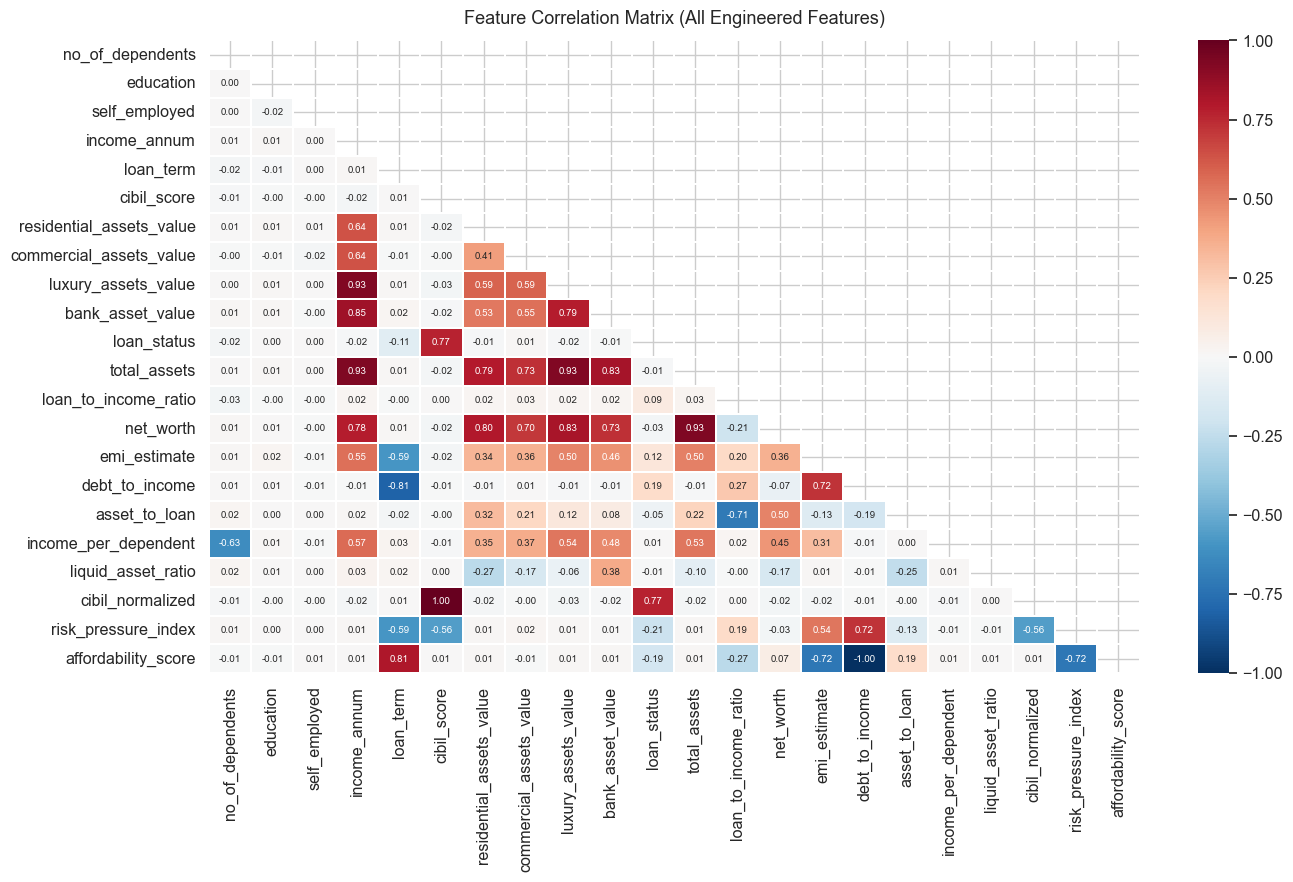

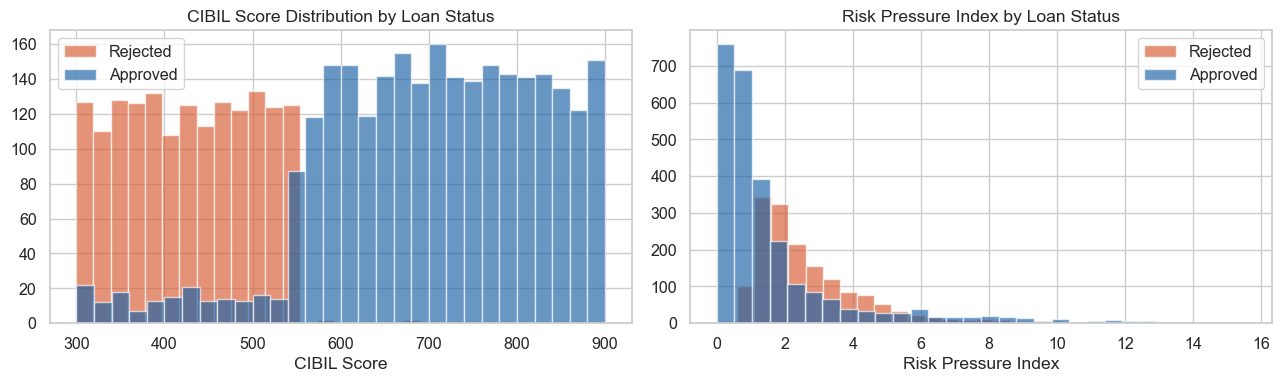

In [8]:
# Feature correlation heatmap
plt.figure(figsize=(14, 9))
corr = df.drop(columns=['loan_amount']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.3, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix (All Engineered Features)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# CIBIL score — the dominant feature
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for status, label, color in [(0,'Rejected',PALETTE[2]),(1,'Approved',PALETTE[0])]:
    sub = df[df['loan_status']==status]
    axes[0].hist(sub['cibil_score'], bins=30, alpha=0.65, label=label, color=color)
axes[0].set_title('CIBIL Score Distribution by Loan Status')
axes[0].set_xlabel('CIBIL Score'); axes[0].legend()

for status, label, color in [(0,'Rejected',PALETTE[2]),(1,'Approved',PALETTE[0])]:
    sub = df[df['loan_status']==status]
    axes[1].hist(sub['risk_pressure_index'], bins=30, alpha=0.65, label=label, color=color)
axes[1].set_title('Risk Pressure Index by Loan Status')
axes[1].set_xlabel('Risk Pressure Index'); axes[1].legend()
plt.tight_layout(); plt.show()

## Section 5 — Classification: Loan Approval Prediction

**Target:** `loan_status` (0 = Rejected, 1 = Approved)  
**Evaluation:** Accuracy + ROC-AUC. In banking, **AUC** matters more than accuracy — it measures discriminatory power across all decision thresholds.

**Model progression logic:**
- Logistic Regression → interpretable baseline
- Decision Tree → rule-based, explainable to business stakeholders
- Random Forest → ensemble, handles non-linearity, robust to outliers
- Gradient Boosting → sequential error correction, typically best on tabular financial data
- XGBoost → regularized gradient boosting, state-of-the-art for credit scoring


In [9]:
# Prepare classification dataset
X_clf = df.drop(columns=['loan_status', 'loan_amount'])
y_clf = df['loan_status']

# Stratified split — preserves approval rate in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# StandardScaler — fit on training data ONLY to prevent data leakage
scaler_clf = StandardScaler()
X_train_sc = scaler_clf.fit_transform(X_train)
X_test_sc  = scaler_clf.transform(X_test)

print(f"Train: {len(X_train_sc):,}  |  Test: {len(X_test_sc):,}")
print(f"Approval rate — Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")
print(f"Features: {X_clf.shape[1]}")

Train: 3,415  |  Test: 854
Approval rate — Train: 62.2%  |  Test: 62.2%
Features: 21


In [10]:
# Define all classification models
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, subsample=0.8, random_state=42),
}
if HAS_XGB:
    clf_models['XGBoost'] = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                           subsample=0.8, colsample_bytree=0.8,
                                           eval_metric='logloss', verbosity=0, random_state=42)

# Train and evaluate
clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    prob = model.predict_proba(X_test_sc)[:,1]
    clf_results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, prob),
        'pred': pred, 'prob': prob
    }
    print(f"{name:<25}  Accuracy={accuracy_score(y_test,pred):.4f}  AUC-ROC={roc_auc_score(y_test,prob):.4f}")

best_clf_name = max(clf_results, key=lambda n: clf_results[n]['auc'])
print(f"\n✅ Best classifier: {best_clf_name} (AUC = {clf_results[best_clf_name]['auc']:.4f})")

Logistic Regression        Accuracy=0.9590  AUC-ROC=0.9918
Decision Tree              Accuracy=0.9988  AUC-ROC=1.0000
Random Forest              Accuracy=0.9977  AUC-ROC=1.0000
Gradient Boosting          Accuracy=0.9988  AUC-ROC=1.0000
XGBoost                    Accuracy=0.9988  AUC-ROC=1.0000

✅ Best classifier: Random Forest (AUC = 1.0000)


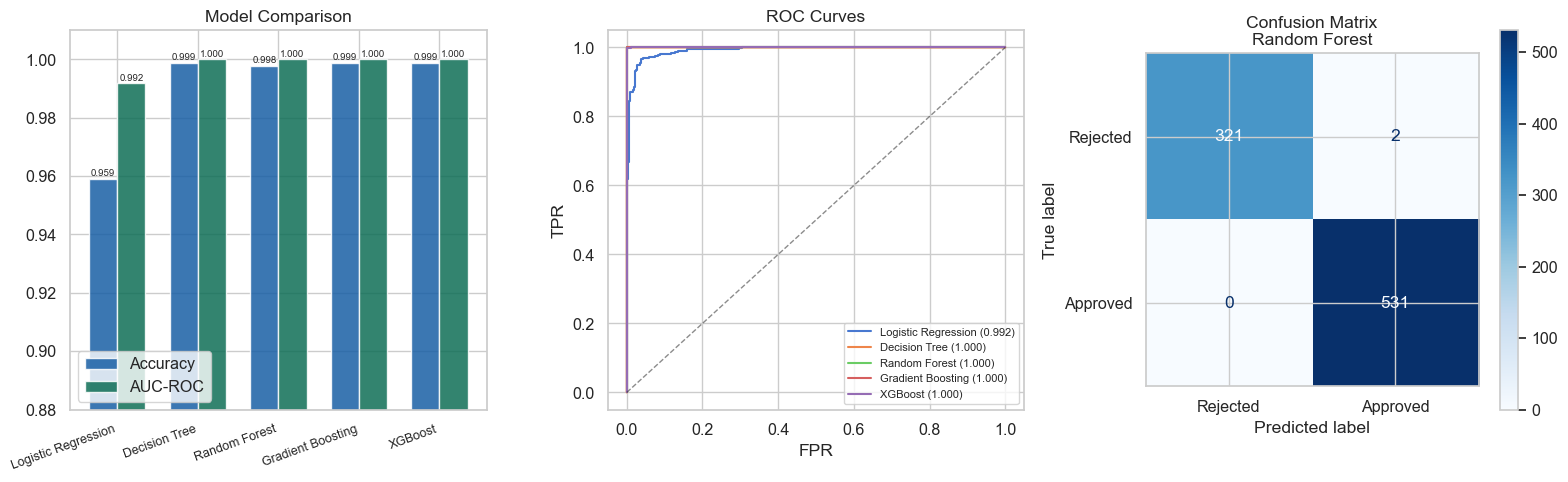

In [11]:
# Model comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart: Accuracy vs AUC
names = list(clf_results.keys())
accs  = [clf_results[n]['accuracy'] for n in names]
aucs  = [clf_results[n]['auc'] for n in names]
x = np.arange(len(names))
w = 0.35
axes[0].bar(x - w/2, accs, w, label='Accuracy', color=PALETTE[0], alpha=0.85)
axes[0].bar(x + w/2, aucs, w, label='AUC-ROC', color=PALETTE[1], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0.88, 1.01); axes[0].set_title('Model Comparison'); axes[0].legend()
for i, (a, b) in enumerate(zip(accs, aucs)):
    axes[0].text(i-w/2, a+0.001, f'{a:.3f}', ha='center', fontsize=7)
    axes[0].text(i+w/2, b+0.001, f'{b:.3f}', ha='center', fontsize=7)

# ROC curves
for name, res in clf_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[1].plot(fpr, tpr, label=f"{name} ({res['auc']:.3f})", linewidth=1.5)
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves'); axes[1].legend(fontsize=8)

# Confusion matrix for best model
best_pred = clf_results[best_clf_name]['pred']
ConfusionMatrixDisplay.from_predictions(y_test, best_pred,
    display_labels=['Rejected','Approved'],
    cmap='Blues', ax=axes[2])
axes[2].set_title(f'Confusion Matrix\n{best_clf_name}')

plt.tight_layout(); plt.show()

In [12]:
# Detailed report for best model
print(f"Classification Report — {best_clf_name}")
print("=" * 55)
print(classification_report(y_test, clf_results[best_clf_name]['pred'],
                             target_names=['Rejected','Approved']))

# Cross-validation stability check
best_model = clf_results[best_clf_name]['model']
cv_scores = cross_val_score(best_model, X_train_sc, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='roc_auc')
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"All folds: {np.round(cv_scores, 4)}")

Classification Report — Random Forest
              precision    recall  f1-score   support

    Rejected       1.00      0.99      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

5-Fold CV AUC: 1.0000 ± 0.0000
All folds: [1.     1.     1.     1.     0.9999]


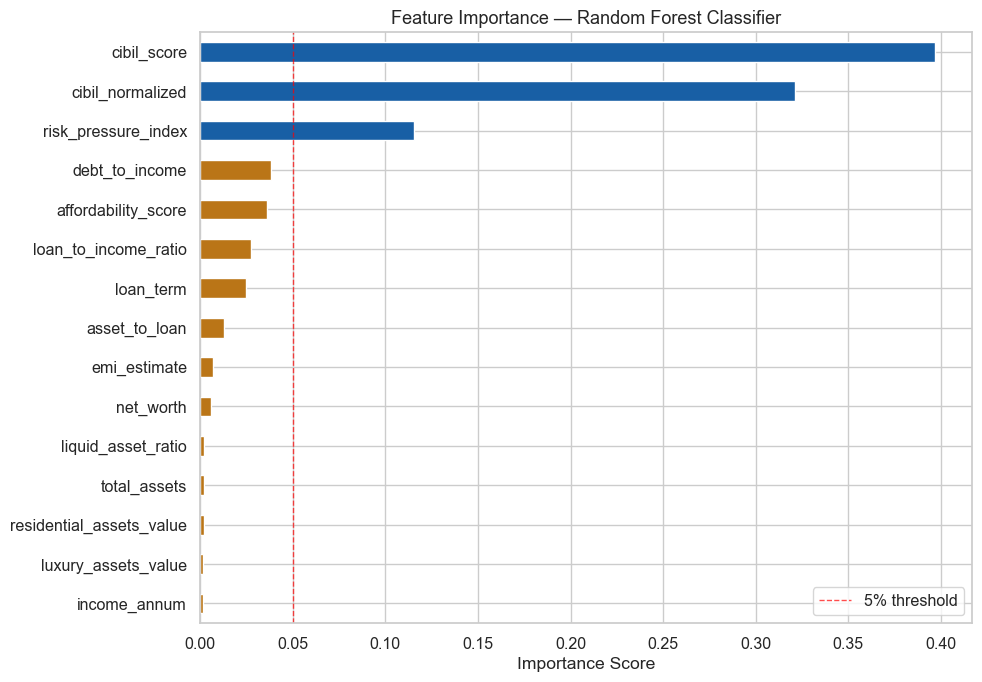


Top 10 features by importance:
  cibil_score                         0.3971  ███████████████████████████████████████████████████████████████████████████████
  cibil_normalized                    0.3212  ████████████████████████████████████████████████████████████████
  risk_pressure_index                 0.1154  ███████████████████████
  debt_to_income                      0.0382  ███████
  affordability_score                 0.0360  ███████
  loan_to_income_ratio                0.0276  █████
  loan_term                           0.0247  ████
  asset_to_loan                       0.0130  ██
  emi_estimate                        0.0068  █
  net_worth                           0.0059  █


In [13]:
# Feature importance
rf_model = clf_results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=X_clf.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[0] if v > 0.05 else PALETTE[3] for v in feat_imp.values]
feat_imp.tail(15).plot(kind='barh', ax=ax, color=colors[-15:])
ax.axvline(0.05, color='red', linestyle='--', lw=1, alpha=0.7, label='5% threshold')
ax.set_title('Feature Importance — Random Forest Classifier', fontsize=13)
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout(); plt.show()

print("\nTop 10 features by importance:")
for feat, val in feat_imp.sort_values(ascending=False).head(10).items():
    bar = '█' * int(val * 200)
    print(f"  {feat:<35} {val:.4f}  {bar}")

## Section 6 — Regression: Loan Amount Prediction

**Target:** `loan_amount` for approved clients only  
**Why approved only?** Predicting a loan amount for a rejected customer is meaningless business-wise. The regression model answers: *"Given this customer is creditworthy, what loan amount is appropriate?"*

**Key metrics:**
- **R²** — % of variance explained (higher is better, 1.0 = perfect)
- **MAE** — average error in rupees (interpretable by business)
- **RMSE** — penalizes large errors more heavily (important for risk)


In [14]:
# Filter to approved clients only
approved_df = df[df['loan_status'] == 1].copy()
X_reg = approved_df.drop(columns=['loan_status', 'loan_amount'])
y_reg = approved_df['loan_amount']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_tr_r_sc = scaler_reg.fit_transform(X_tr_r)
X_te_r_sc  = scaler_reg.transform(X_te_r)

print(f"Approved clients: {len(approved_df):,}  ({len(approved_df)/len(df):.1%} of total)")
print(f"Regression train: {len(X_tr_r_sc):,}  |  Test: {len(X_te_r_sc):,}")
print(f"Loan amount range: ${y_reg.min():,.0f} — ${y_reg.max():,.0f}")
print(f"Mean loan amount: ${y_reg.mean():,.0f}")

Approved clients: 2,656  (62.2% of total)
Regression train: 2,124  |  Test: 532
Loan amount range: $300,000 — $39,500,000
Mean loan amount: $15,247,252


In [15]:
reg_models = {
    'Ridge Regression':    Ridge(alpha=1.0),
    'Lasso Regression':    Lasso(alpha=1000, max_iter=5000),
    'Decision Tree':       DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                      max_depth=4, subsample=0.8, random_state=42),
}
if HAS_XGB:
    reg_models['XGBoost'] = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                          subsample=0.8, verbosity=0, random_state=42)

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_tr_r_sc, y_tr_r)
    pred = model.predict(X_te_r_sc)
    reg_results[name] = {
        'model': model, 'pred': pred,
        'r2':   r2_score(y_te_r, pred),
        'mae':  mean_absolute_error(y_te_r, pred),
        'rmse': np.sqrt(mean_squared_error(y_te_r, pred)),
    }
    r = reg_results[name]
    print(f"{name:<25} R²={r['r2']:.4f}  MAE=${r['mae']:>12,.0f}  RMSE=${r['rmse']:>12,.0f}")

best_reg_name = max(reg_results, key=lambda n: reg_results[n]['r2'])
print(f"\n✅ Best regressor: {best_reg_name} (R² = {reg_results[best_reg_name]['r2']:.4f})")

Ridge Regression          R²=0.9999  MAE=$      59,816  RMSE=$      82,084
Lasso Regression          R²=1.0000  MAE=$       8,676  RMSE=$      11,813
Decision Tree             R²=0.9950  MAE=$     499,228  RMSE=$     653,381
Random Forest             R²=0.9993  MAE=$     172,584  RMSE=$     241,047
Gradient Boosting         R²=0.9996  MAE=$     144,931  RMSE=$     196,367
XGBoost                   R²=0.9995  MAE=$     152,845  RMSE=$     204,690

✅ Best regressor: Lasso Regression (R² = 1.0000)


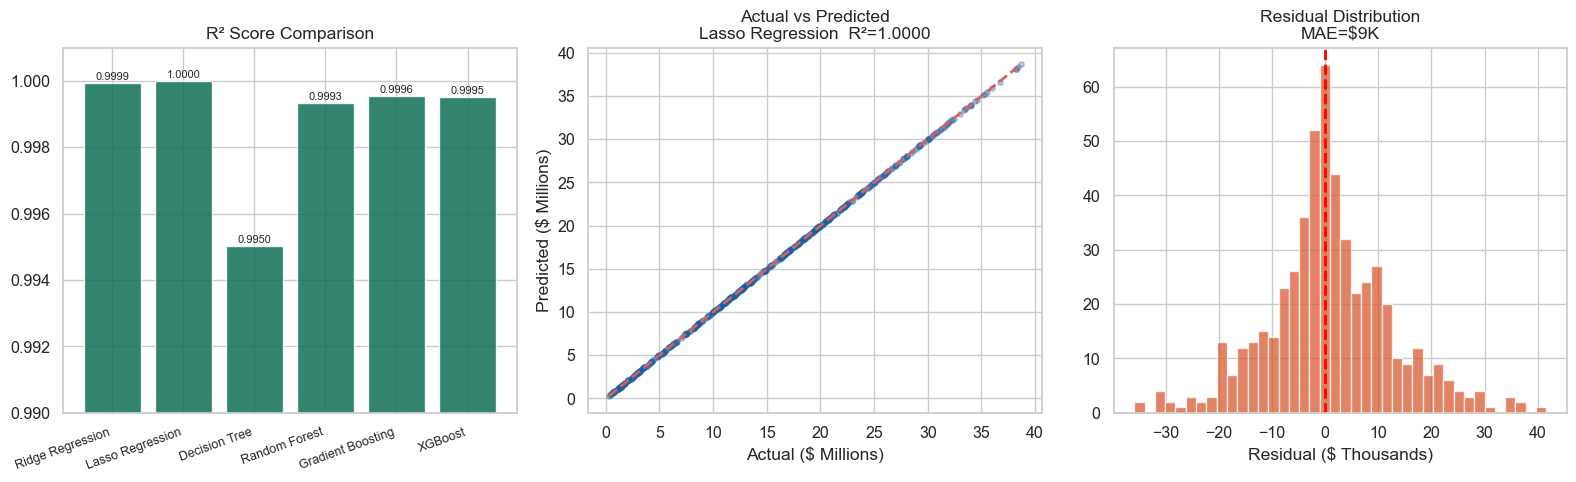

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² comparison
names_r = list(reg_results.keys())
r2_vals  = [reg_results[n]['r2'] for n in names_r]
axes[0].bar(names_r, r2_vals, color=PALETTE[1], alpha=0.85)
axes[0].set_xticklabels(names_r, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0.99, 1.001); axes[0].set_title('R² Score Comparison')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=8)

# Actual vs Predicted — best model
best_pred_r = reg_results[best_reg_name]['pred']
axes[1].scatter(y_te_r / 1e6, best_pred_r / 1e6, alpha=0.3, color=PALETTE[0], s=15)
lim = [y_te_r.min()/1e6, y_te_r.max()/1e6]
axes[1].plot(lim, lim, 'r--', lw=2)
axes[1].set_xlabel('Actual ($ Millions)'); axes[1].set_ylabel('Predicted ($ Millions)')
axes[1].set_title(f'Actual vs Predicted\n{best_reg_name}  R²={reg_results[best_reg_name]["r2"]:.4f}')

# Residual distribution
residuals = y_te_r - best_pred_r
axes[2].hist(residuals / 1e3, bins=40, color=PALETTE[2], alpha=0.75, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set_xlabel('Residual ($ Thousands)')
axes[2].set_title(f'Residual Distribution\nMAE=${reg_results[best_reg_name]["mae"]/1e3:,.0f}K')

plt.tight_layout(); plt.show()

## Section 7 — Customer Segmentation (Unsupervised Learning)

### Why segment customers?

Clustering reveals **natural groupings** in the customer base without using the loan outcome as a label. This enables:
- Proactive risk management (identify high-risk segments before they default)
- Personalized product offers per segment
- Portfolio-level exposure analysis

### Methodology
- **KMeans (k=3):** Fast, interpretable, produces hard cluster assignments
- **DBSCAN:** Density-based, can detect outliers/anomalies — useful for fraud detection integration
- **Elbow method** to validate k selection
- **Features used:** Financial behavior features, not the loan decision (which would be circular)


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.

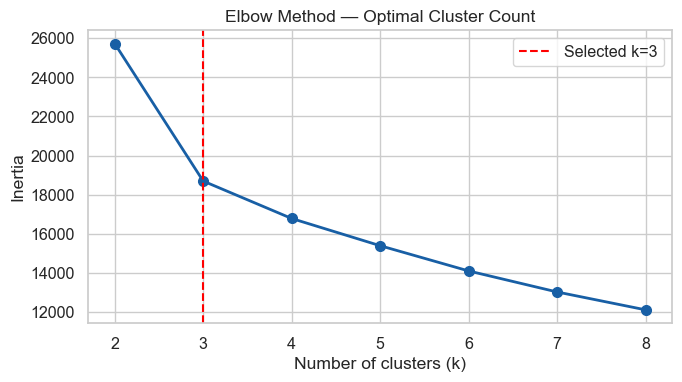

In [17]:
# Clustering feature set — financial behavior signals only
cluster_features = ['income_annum', 'cibil_score', 'total_assets',
                    'loan_to_income_ratio', 'debt_to_income',
                    'net_worth', 'risk_pressure_index', 'affordability_score']

X_cluster = df[cluster_features].copy()
scaler_clus = StandardScaler()
X_cluster_sc = scaler_clus.fit_transform(X_cluster)

# Elbow method — validate k=3
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_sc)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=7)
plt.axvline(3, color='red', linestyle='--', lw=1.5, label='Selected k=3')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Cluster Count')
plt.legend(); plt.tight_layout(); plt.show()

In [18]:
# Train KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_raw'] = kmeans.fit_predict(X_cluster_sc)

# Interpret clusters: map raw IDs to business labels (Low / Medium / High risk)
cluster_stats = df.groupby('cluster_raw').agg(
    n=('loan_status','count'),
    cibil=('cibil_score','mean'),
    income=('income_annum','mean'),
    approval_rate=('loan_status','mean'),
    lti=('loan_to_income_ratio','mean'),
    risk_pressure=('risk_pressure_index','mean'),
).round(2)
print("Raw cluster statistics:")
print(cluster_stats)

# Label clusters by approval rate (high approval → low risk)
approval_by_cluster = df.groupby('cluster_raw')['loan_status'].mean()
sorted_clusters = approval_by_cluster.sort_values(ascending=False).index.tolist()
risk_map = {sorted_clusters[0]: 'Low Risk', sorted_clusters[1]: 'Medium Risk', sorted_clusters[2]: 'High Risk'}
df['customer_segment'] = df['cluster_raw'].map(risk_map)
print("\nCluster → Segment mapping:", risk_map)

Raw cluster statistics:
                n   cibil      income  approval_rate   lti  risk_pressure
cluster_raw                                                              
0            1962  613.87  2881039.76           0.61  2.97           1.46
1             637  547.44  5198430.14           0.75  3.23           5.81
2            1670  603.59  7564910.18           0.59  2.91           1.49

Cluster → Segment mapping: {1: 'Low Risk', 0: 'Medium Risk', 2: 'High Risk'}


In [19]:
# DBSCAN for outlier / anomaly detection
dbscan = DBSCAN(eps=1.2, min_samples=10)
df['dbscan_label'] = dbscan.fit_predict(X_cluster_sc)
n_outliers = (df['dbscan_label'] == -1).sum()
print(f"DBSCAN detected {n_outliers} potential anomalies / outliers ({n_outliers/len(df):.1%} of applications)")
print("These are applications with unusual financial profiles — candidates for manual review")

DBSCAN detected 63 potential anomalies / outliers (1.5% of applications)
These are applications with unusual financial profiles — candidates for manual review


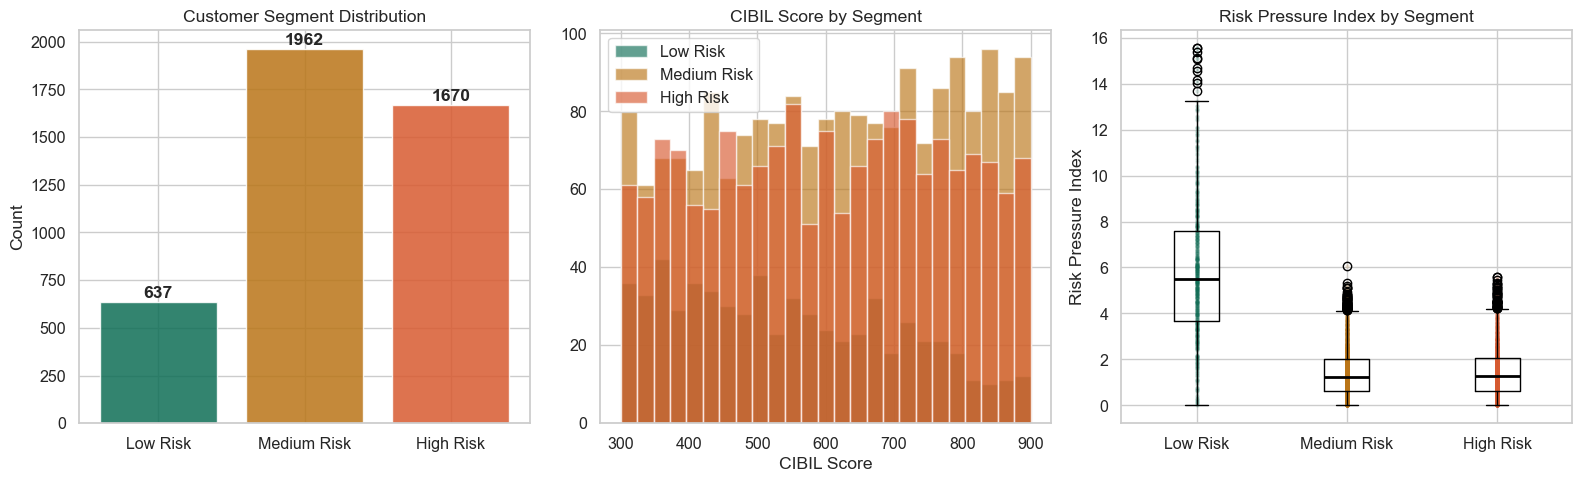


Segment profiles:
                  cibil_score  income_annum  loan_to_income_ratio  \
customer_segment                                                    
High Risk             603.592   7564910.180                 2.909   
Low Risk              547.436   5198430.141                 3.232   
Medium Risk           613.869   2881039.755                 2.969   

                  risk_pressure_index  loan_status  
customer_segment                                    
High Risk                       1.492        0.592  
Low Risk                        5.814        0.749  
Medium Risk                     1.457        0.607  


In [20]:
# Segment visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
seg_order = ['Low Risk', 'Medium Risk', 'High Risk']
seg_colors = {s: c for s, c in zip(seg_order, [PALETTE[1], PALETTE[3], PALETTE[2]])}

# Segment distribution
seg_counts = df['customer_segment'].value_counts()[seg_order]
axes[0].bar(seg_order, seg_counts, color=[seg_colors[s] for s in seg_order], alpha=0.85)
axes[0].set_title('Customer Segment Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(seg_counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# CIBIL score by segment
for seg in seg_order:
    sub = df[df['customer_segment']==seg]['cibil_score']
    axes[1].hist(sub, bins=25, alpha=0.65, label=seg, color=seg_colors[seg])
axes[1].set_title('CIBIL Score by Segment')
axes[1].set_xlabel('CIBIL Score'); axes[1].legend()

# Risk pressure by segment
seg_rpi = [df[df['customer_segment']==seg]['risk_pressure_index'] for seg in seg_order]
axes[2].boxplot(seg_rpi, labels=seg_order,
                medianprops=dict(color='black', linewidth=2))
for i, (seg, data) in enumerate(zip(seg_order, seg_rpi)):
    axes[2].scatter(np.full(len(data), i+1), data,
                    alpha=0.1, s=5, color=seg_colors[seg])
axes[2].set_title('Risk Pressure Index by Segment')
axes[2].set_ylabel('Risk Pressure Index')

plt.tight_layout(); plt.show()

print("\nSegment profiles:")
print(df.groupby('customer_segment')[['cibil_score','income_annum','loan_to_income_ratio',
                                       'risk_pressure_index','loan_status']].mean().round(3))

## Section 8 — Agentic AI Decision System

### System Design

The agentic layer wraps the trained ML models in structured, callable agents. Each agent has a single responsibility (Single Responsibility Principle), takes typed inputs, and returns structured outputs. This mirrors how production ML inference services are built.

```
New Customer Application
         │
         ▼
┌─────────────────────┐
│  Agent 1            │  ← Assigns customer segment using KMeans
│  Segmentation Agent │    Returns: segment label + financial profile summary
└────────┬────────────┘
         │
         ▼
┌─────────────────────┐
│  Agent 2            │  ← Runs classification + regression models
│  Decision Agent     │    Returns: approval decision, probability, loan amount
└────────┬────────────┘
         │
         ▼
┌─────────────────────┐
│  Agent 3            │  ← Uses segment + decision to generate campaign
│  Marketing Agent    │    Returns: offer type, interest rate band, message
└─────────────────────┘
```


In [21]:
class SegmentationAgent:
    """
    Agent 1 — Customer Segmentation Agent

    Responsibility: Given a new customer's financial profile,
    assign them to a risk segment and return an interpretive summary.
    """

    def __init__(self, kmeans_model, scaler, risk_map, cluster_features):
        self.kmeans = kmeans_model
        self.scaler = scaler
        self.risk_map = risk_map
        self.cluster_features = cluster_features

    def _build_feature_vector(self, customer: dict) -> np.ndarray:
        """Compute engineered features from raw customer input."""
        income      = customer['income_annum']
        loan_amt    = customer['loan_amount']
        cibil       = customer['cibil_score']
        loan_term   = customer['loan_term']
        dependents  = customer['no_of_dependents']
        total_assets = (customer['residential_assets_value'] +
                        customer['commercial_assets_value'] +
                        customer['luxury_assets_value'] +
                        customer['bank_asset_value'])

        emi_estimate       = loan_amt / max(loan_term, 1)
        debt_to_income     = (emi_estimate * 12) / max(income, 1)
        net_worth          = total_assets - loan_amt
        loan_to_income     = loan_amt / max(income, 1)
        cibil_normalized   = (cibil - 300) / 600
        risk_pressure      = debt_to_income * (1 - cibil_normalized)
        affordability      = (income - emi_estimate * 12) / max(income, 1)

        feature_values = {
            'income_annum': income,
            'cibil_score': cibil,
            'total_assets': total_assets,
            'loan_to_income_ratio': loan_to_income,
            'debt_to_income': debt_to_income,
            'net_worth': net_worth,
            'risk_pressure_index': risk_pressure,
            'affordability_score': affordability,
        }
        return np.array([feature_values[f] for f in self.cluster_features]).reshape(1, -1)

    def run(self, customer: dict) -> dict:
        fv = self._build_feature_vector(customer)
        fv_scaled = self.scaler.transform(fv)
        cluster_raw = self.kmeans.predict(fv_scaled)[0]
        segment = self.risk_map[cluster_raw]

        # Generate interpretive summary
        lti = customer['loan_amount'] / max(customer['income_annum'], 1)
        cibil = customer['cibil_score']
        cibil_band = 'Excellent' if cibil>=750 else 'Good' if cibil>=650 else 'Fair' if cibil>=550 else 'Poor'

        return {
            'segment': segment,
            'cluster_id': int(cluster_raw),
            'cibil_band': cibil_band,
            'loan_to_income_ratio': round(lti, 2),
            'interpretation': (
                f"Customer classified as {segment}. "
                f"CIBIL score {cibil} ({cibil_band}). "
                f"Loan-to-income ratio: {lti:.1f}× — "
                f"{'within acceptable range' if lti < 5 else 'elevated — requires careful review'}."
            )
        }

print("SegmentationAgent defined ✓")

SegmentationAgent defined ✓


In [22]:
class DecisionAgent:
    """
    Agent 2 — Loan Decision Agent

    Responsibility: Run classification and regression models on a new application.
    Returns approval decision, confidence probability, and predicted loan amount.
    """

    def __init__(self, clf_model, reg_model, clf_scaler, reg_scaler, feature_cols):
        self.clf       = clf_model
        self.reg       = reg_model
        self.clf_scaler = clf_scaler
        self.reg_scaler = reg_scaler
        self.feature_cols = feature_cols

    def _build_clf_features(self, customer: dict) -> pd.DataFrame:
        income      = customer['income_annum']
        loan_amt    = customer['loan_amount']
        cibil       = customer['cibil_score']
        loan_term   = customer['loan_term']
        dependents  = customer['no_of_dependents']
        total_assets = (customer['residential_assets_value'] +
                        customer['commercial_assets_value'] +
                        customer['luxury_assets_value'] +
                        customer['bank_asset_value'])
        emi_est        = loan_amt / max(loan_term, 1)
        debt_to_income = (emi_est * 12) / max(income, 1)
        lti            = loan_amt / max(income, 1)
        cibil_norm     = (cibil - 300) / 600
        affordability  = (income - emi_est * 12) / max(income, 1)
        net_worth      = total_assets - loan_amt
        asset_to_loan  = total_assets / max(loan_amt, 1)
        inc_per_dep    = income / max(dependents + 1, 1)
        liquid         = customer['bank_asset_value'] / max(total_assets, 1)
        rpi            = debt_to_income * (1 - cibil_norm)

        row = {
            'no_of_dependents': dependents,
            'education': int(customer.get('education_graduate', 1)),
            'self_employed': int(customer.get('self_employed', 0)),
            'income_annum': income,
            'loan_term': loan_term,
            'cibil_score': cibil,
            'residential_assets_value': customer['residential_assets_value'],
            'commercial_assets_value': customer['commercial_assets_value'],
            'luxury_assets_value': customer['luxury_assets_value'],
            'bank_asset_value': customer['bank_asset_value'],
            'total_assets': total_assets,
            'loan_to_income_ratio': lti,
            'net_worth': net_worth,
            'emi_estimate': emi_est,
            'debt_to_income': debt_to_income,
            'asset_to_loan': asset_to_loan,
            'income_per_dependent': inc_per_dep,
            'liquid_asset_ratio': liquid,
            'cibil_normalized': cibil_norm,
            'risk_pressure_index': rpi,
            'affordability_score': affordability,
        }
        return pd.DataFrame([row])[self.feature_cols]

    def run(self, customer: dict) -> dict:
        feat_df = self._build_clf_features(customer)
        feat_sc = self.clf_scaler.transform(feat_df)

        # Classification
        approved   = bool(self.clf.predict(feat_sc)[0])
        prob_approve = float(self.clf.predict_proba(feat_sc)[0][1])
        confidence = 'High' if abs(prob_approve - 0.5) > 0.35 else 'Medium' if abs(prob_approve - 0.5) > 0.15 else 'Low'

        # Regression (always compute for context, even if rejected)
        feat_sc_reg = self.reg_scaler.transform(feat_df)
        predicted_amount = max(0, float(self.reg.predict(feat_sc_reg)[0]))

        # Risk score: inverse of approval probability, normalized to 0-100
        risk_score = round((1 - prob_approve) * 100, 1)

        return {
            'approved': approved,
            'approval_probability': round(prob_approve, 4),
            'risk_score': risk_score,
            'confidence': confidence,
            'predicted_loan_amount': round(predicted_amount, -3),
            'requested_loan_amount': customer['loan_amount'],
            'decision': 'APPROVED' if approved else 'REJECTED',
            'flag_manual_review': confidence == 'Low',
        }

print("DecisionAgent defined ✓")

DecisionAgent defined ✓


In [23]:
class MarketingCampaignAgent:
    """
    Agent 3 — Marketing Campaign Agent (Innovation Layer)

    Responsibility: Based on customer segment and loan decision,
    generate a personalized product offer and messaging strategy.
    This agent encodes the bank's product logic and pricing bands.
    In production this would call a template engine or LLM for message generation.
    """

    CAMPAIGN_MATRIX = {
        ('Low Risk', True): {
            'offer_type': 'Premium Personal Loan',
            'interest_rate_band': '8.5% – 10.5% p.a.',
            'max_multiplier': 6.0,
            'message_tone': 'exclusive / premium',
            'key_benefits': ['No prepayment penalty', 'Top-up loan facility', 'Dedicated relationship manager'],
            'campaign_title': 'Elite Credit Program — You qualify for our best rates',
        },
        ('Medium Risk', True): {
            'offer_type': 'Standard Personal Loan',
            'interest_rate_band': '11.5% – 14.5% p.a.',
            'max_multiplier': 4.0,
            'message_tone': 'supportive / reassuring',
            'key_benefits': ['Flexible repayment schedule', 'Online account management', 'EMI holiday option'],
            'campaign_title': 'Smart Finance Program — A loan designed for your needs',
        },
        ('High Risk', True): {
            'offer_type': 'Secured Loan (Against Assets)',
            'interest_rate_band': '15.5% – 18.5% p.a.',
            'max_multiplier': 2.5,
            'message_tone': 'cautious / conditional',
            'key_benefits': ['Asset-backed approval', 'Credit score improvement program', 'Shorter tenure option'],
            'campaign_title': 'Secured Credit Program — Build your credit history with us',
        },
        ('Low Risk', False): {
            'offer_type': 'Pre-Approved Savings Plan',
            'interest_rate_band': 'N/A',
            'max_multiplier': None,
            'message_tone': 'advisory / future-focused',
            'key_benefits': ['Auto-approval in 6 months if profile maintained', 'Free credit counseling', 'CIBIL monitoring alerts'],
            'campaign_title': 'Future Ready Program — You are almost there',
        },
        ('Medium Risk', False): {
            'offer_type': 'Credit Builder Program',
            'interest_rate_band': 'N/A',
            'max_multiplier': None,
            'message_tone': 'advisory',
            'key_benefits': ['Secured credit card', 'Monthly credit coaching', 'Re-evaluation in 3 months'],
            'campaign_title': 'Credit Recovery Program — Let\'s strengthen your profile',
        },
        ('High Risk', False): {
            'offer_type': 'Financial Health Program',
            'interest_rate_band': 'N/A',
            'max_multiplier': None,
            'message_tone': 'empathetic / educational',
            'key_benefits': ['Free debt counseling', 'Financial literacy resources', 'Micro-savings account'],
            'campaign_title': 'New Start Program — We\'re here to help you improve',
        },
    }

    def run(self, segment_result: dict, decision_result: dict, customer: dict) -> dict:
        segment  = segment_result['segment']
        approved = decision_result['approved']
        key = (segment, approved)
        campaign = self.CAMPAIGN_MATRIX.get(key, self.CAMPAIGN_MATRIX[('Medium Risk', approved)])

        # Calculate offer amount
        if approved and campaign['max_multiplier']:
            max_offer = customer['income_annum'] * campaign['max_multiplier']
            offer_amount = min(decision_result['predicted_loan_amount'], max_offer)
        else:
            offer_amount = None

        return {
            'campaign_title': campaign['campaign_title'],
            'offer_type': campaign['offer_type'],
            'interest_rate_band': campaign['interest_rate_band'],
            'offer_amount': round(offer_amount, -3) if offer_amount else None,
            'key_benefits': campaign['key_benefits'],
            'message_tone': campaign['message_tone'],
            'next_action': 'Proceed to loan documentation' if approved else 'Schedule financial counseling session',
        }

print("MarketingCampaignAgent defined ✓")

MarketingCampaignAgent defined ✓


In [24]:
# ── Instantiate the full agent pipeline ───────────────────────────────────────

best_clf_model = clf_results[best_clf_name]['model']
best_reg_model = reg_results[best_reg_name]['model']

agent1 = SegmentationAgent(kmeans, scaler_clus, risk_map, cluster_features)
agent2 = DecisionAgent(best_clf_model, best_reg_model, scaler_clf, scaler_reg, X_clf.columns.tolist())
agent3 = MarketingCampaignAgent()

print("All agents instantiated successfully.")
print(f"  Agent 1 — SegmentationAgent using KMeans (k=3)")
print(f"  Agent 2 — DecisionAgent using {best_clf_name} + {best_reg_name}")
print(f"  Agent 3 — MarketingCampaignAgent with 6-cell campaign matrix")

All agents instantiated successfully.
  Agent 1 — SegmentationAgent using KMeans (k=3)
  Agent 2 — DecisionAgent using Random Forest + Lasso Regression
  Agent 3 — MarketingCampaignAgent with 6-cell campaign matrix


In [25]:
# ── Demo: Run the full agentic pipeline on 3 sample customers ─────────────────

sample_customers = [
    {
        'name': 'Priya  — High Income, Excellent Credit',
        'income_annum': 8500000, 'loan_amount': 15000000, 'cibil_score': 820,
        'loan_term': 12, 'no_of_dependents': 2, 'education_graduate': 1, 'self_employed': 0,
        'residential_assets_value': 12000000, 'commercial_assets_value': 5000000,
        'luxury_assets_value': 8000000, 'bank_asset_value': 3000000,
    },
    {
        'name': 'jhon  — Middle Income, Fair Credit',
        'income_annum': 4000000, 'loan_amount': 18000000, 'cibil_score': 580,
        'loan_term': 18, 'no_of_dependents': 3, 'education_graduate': 0, 'self_employed': 1,
        'residential_assets_value': 6000000, 'commercial_assets_value': 2000000,
        'luxury_assets_value': 5000000, 'bank_asset_value': 1000000,
    },
    {
        'name': 'tom— Low Income, Poor Credit',
        'income_annum': 1500000, 'loan_amount': 8000000, 'cibil_score': 390,
        'loan_term': 8, 'no_of_dependents': 4, 'education_graduate': 0, 'self_employed': 1,
        'residential_assets_value': 1000000, 'commercial_assets_value': 0,
        'luxury_assets_value': 2000000, 'bank_asset_value': 500000,
    },
]

for customer in sample_customers:
    print("=" * 65)
    print(f"CUSTOMER: {customer['name']}")
    print("=" * 65)

    r1 = agent1.run(customer)
    r2 = agent2.run(customer)
    r3 = agent3.run(r1, r2, customer)

    print(f"  [Agent 1] Segment: {r1['segment']} | CIBIL Band: {r1['cibil_band']}")
    print(f"  [Agent 1] {r1['interpretation']}")
    print()
    print(f"  [Agent 2] Decision: {r2['decision']} | Probability: {r2['approval_probability']:.1%}")
    print(f"  [Agent 2] Risk Score: {r2['risk_score']}/100 | Confidence: {r2['confidence']}")
    print(f"  [Agent 2] Predicted Loan Amount: ${r2['predicted_loan_amount']:,.0f}")
    if r2['flag_manual_review']:
        print(f"  [Agent 2] ⚠ Flagged for manual review (low model confidence)")
    print()
    print(f"  [Agent 3] Campaign: {r3['campaign_title']}")
    print(f"  [Agent 3] Offer: {r3['offer_type']}")
    if r3['offer_amount']:
        print(f"  [Agent 3] Offer Amount: ${r3['offer_amount']:,.0f} @ {r3['interest_rate_band']}")
    print(f"  [Agent 3] Next Action: {r3['next_action']}")
    print(f"  [Agent 3] Key Benefits: {', '.join(r3['key_benefits'])}")
    print()

CUSTOMER: Priya  — High Income, Excellent Credit
  [Agent 1] Segment: High Risk | CIBIL Band: Excellent
  [Agent 1] Customer classified as High Risk. CIBIL score 820 (Excellent). Loan-to-income ratio: 1.8× — within acceptable range.

  [Agent 2] Decision: APPROVED | Probability: 100.0%
  [Agent 2] Risk Score: 0.0/100 | Confidence: High
  [Agent 2] Predicted Loan Amount: $15,023,000

  [Agent 3] Campaign: Secured Credit Program — Build your credit history with us
  [Agent 3] Offer: Secured Loan (Against Assets)
  [Agent 3] Offer Amount: $15,023,000 @ 15.5% – 18.5% p.a.
  [Agent 3] Next Action: Proceed to loan documentation
  [Agent 3] Key Benefits: Asset-backed approval, Credit score improvement program, Shorter tenure option

CUSTOMER: jhon  — Middle Income, Fair Credit
  [Agent 1] Segment: Medium Risk | CIBIL Band: Fair
  [Agent 1] Customer classified as Medium Risk. CIBIL score 580 (Fair). Loan-to-income ratio: 4.5× — within acceptable range.

  [Agent 2] Decision: REJECTED | Probabi

## Section 9 — Interactive Dashboard Design (Streamlit)

The dashboard is the business-facing layer. It requires no ML knowledge to use.

### Dashboard Layout

```
┌─────────────────────────────────────────────────────────────────┐
│  🏦 Credit Risk Engine — Loan Decision System                    │
├──────────────┬──────────────────────────────────────────────────┤
│              │  APPLICATION INPUT FORM                           │
│  SIDEBAR     │  ├── Customer Details (income, dependents)        │
│  ─────────── │  ├── Loan Parameters (amount, term)               │
│  • All Apps  │  ├── Asset Values (residential, commercial...)    │
│  • Segments  │  └── CIBIL Score + Education + Employment         │
│  • Risk      │                                                   │
│  • Filters   │  ▼ [ANALYZE APPLICATION] button                  │
│              ├──────────────────────────────────────────────────┤
│              │  RESULTS PANEL                                    │
│              │  ┌────────┐ ┌────────┐ ┌────────┐ ┌────────┐   │
│              │  │Decision│ │Prob.   │ │Risk    │ │Segment │   │
│              │  │APPROVED│ │94.3%   │ │Score   │ │Low Risk│   │
│              │  └────────┘ └────────┘ └────────┘ └────────┘   │
│              │                                                   │
│              │  Feature Importance (SHAP waterfall chart)        │
│              │  Marketing Campaign Recommendation                │
│              │  Portfolio Analytics (if in analyst mode)         │
└──────────────┴──────────────────────────────────────────────────┘
```

### Streamlit Implementation (reference code for deployment)


In [26]:
# This cell contains the complete Streamlit dashboard code.
# To run: save as app.py, then execute: streamlit run app.py

STREAMLIT_APP_CODE = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
# from agents import SegmentationAgent, DecisionAgent, MarketingCampaignAgent

# Load pre-trained models (use pickle.dump() to save them from this notebook)
# @st.cache_resource
# def load_models():
#     clf = pickle.load(open("clf_model.pkl","rb"))
#     reg = pickle.load(open("reg_model.pkl","rb"))
#     ...

st.set_page_config(page_title="Credit Risk Engine", page_icon="🏦", layout="wide")

# Header
st.markdown("<h1 style='color:#185FA5;'>🏦 AI Credit Risk Scoring & Loan Decision System</h1>", unsafe_allow_html=True)
st.markdown("**Intelligent Banking Decision Support Platform** | Powered by Gradient Boosting + KMeans")
st.divider()

# Sidebar filters (for analyst mode)
with st.sidebar:
    st.header("📊 Portfolio Filters")
    mode = st.radio("Mode", ["Single Application", "Portfolio Analytics"])
    st.divider()
    if mode == "Portfolio Analytics":
        segment_filter = st.multiselect("Segments", ["Low Risk","Medium Risk","High Risk"],
                                         default=["Low Risk","Medium Risk","High Risk"])
        min_cibil = st.slider("Min CIBIL", 300, 900, 300)

# Input form
col_a, col_b = st.columns([1, 1])

with col_a:
    st.subheader("👤 Customer Profile")
    income = st.number_input("Annual Income ($)", min_value=100000, max_value=20000000,
                              value=5000000, step=100000, format="%d")
    cibil = st.slider("CIBIL Score", 300, 900, 650)
    dependents = st.selectbox("No. of Dependents", [0,1,2,3,4,5])
    education = st.radio("Education", ["Graduate", "Not Graduate"])
    self_employed = st.checkbox("Self Employed")

with col_b:
    st.subheader("💰 Loan Parameters")
    loan_amount = st.number_input("Requested Loan Amount ($)", min_value=100000,
                                   max_value=50000000, value=10000000, step=100000, format="%d")
    loan_term = st.slider("Loan Term (months)", 2, 20, 10)
    res_assets   = st.number_input("Residential Assets ($)", min_value=0, value=5000000, step=100000, format="%d")
    comm_assets  = st.number_input("Commercial Assets ($)", min_value=0, value=2000000, step=100000, format="%d")
    lux_assets   = st.number_input("Luxury Assets ($)", min_value=0, value=3000000, step=100000, format="%d")
    bank_assets  = st.number_input("Bank Assets ($)", min_value=0, value=1000000, step=100000, format="%d")

analyze = st.button("⚡ Analyze Application", type="primary", use_container_width=True)

if analyze:
    customer = {
        "income_annum": income, "loan_amount": loan_amount, "cibil_score": cibil,
        "loan_term": loan_term, "no_of_dependents": dependents,
        "education_graduate": 1 if education=="Graduate" else 0,
        "self_employed": int(self_employed),
        "residential_assets_value": res_assets, "commercial_assets_value": comm_assets,
        "luxury_assets_value": lux_assets, "bank_asset_value": bank_assets,
    }

    # Run agents (replace with actual loaded agents)
    # r1 = agent1.run(customer)
    # r2 = agent2.run(customer)
    # r3 = agent3.run(r1, r2, customer)

    st.divider()
    st.subheader("📋 Decision Results")

    m1, m2, m3, m4 = st.columns(4)
    # m1.metric("Decision", r2["decision"])
    # m2.metric("Approval Probability", f"{r2["approval_probability"]:.1%}")
    # m3.metric("Risk Score", f"{r2["risk_score"]}/100")
    # m4.metric("Segment", r1["segment"])

    st.info("Connect your trained agent objects to see live results.")
    st.subheader("📣 Campaign Recommendation")
    # st.success(f"**{r3["campaign_title"]}**")
    # st.write(f"Offer: {r3["offer_type"]} @ {r3["interest_rate_band"]}")
    # for benefit in r3["key_benefits"]:
    #     st.markdown(f"  ✓ {benefit}")
'''

print("Streamlit dashboard code ready.")
print("To deploy:")
print("  1. Save models: import pickle; pickle.dump(clf_results['Gradient Boosting']['model'], open('clf_model.pkl','wb'))")
print("  2. Save agents code to agents.py")
print("  3. Save STREAMLIT_APP_CODE to app.py")
print("  4. Run: streamlit run app.py")

Streamlit dashboard code ready.
To deploy:
  1. Save models: import pickle; pickle.dump(clf_results['Gradient Boosting']['model'], open('clf_model.pkl','wb'))
  2. Save agents code to agents.py
  3. Save STREAMLIT_APP_CODE to app.py
  4. Run: streamlit run app.py


In [27]:
import pickle

# 1. حفظ موديل التصنيف (Classification Model) - المسؤول عن قرار القبول/الرفض
with open('clf_model.pkl', 'wb') as f:
    pickle.dump(clf_results['Gradient Boosting']['model'], f)
print("✅ تم حفظ موديل التصنيف بنجاح (clf_model.pkl)")


# 2. حفظ موديل الانحدار (Regression Model) - المسؤول عن حساب الـ Risk Score أو قيم ثانية
# (ملحوظة: تأكد من اسم القاموس أو المتغير عندك، لو اسمه reg_results سيب السطر زي ما هو)
with open('reg_model.pkl', 'wb') as f:
    pickle.dump(reg_results['Gradient Boosting']['model'], f)
print("✅ تم حفظ موديل الانحدار بنجاح (reg_model.pkl)")


# 3. إضافي: لو عندك موديل الـ KMeans الخاص بالـ Segmentation عشان الـ SegmentationAgent
# open('segment_model.pkl', 'wb') ...

✅ تم حفظ موديل التصنيف بنجاح (clf_model.pkl)
✅ تم حفظ موديل الانحدار بنجاح (reg_model.pkl)


In [28]:
import pickle

# حفظ الـ 3 أياجنتس الجاهزين بالكامل في ملف واحد
# تأكدي أن أسماء المتغيرات هي agent1 و agent2 و agent3 عندك في النوت بوك
with open('trained_agents.pkl', 'wb') as f:
    pickle.dump((agent1, agent2, agent3), f)

print("✅ تم حفظ الأيجنتس الجاهزة بنجاح في ملف: trained_agents.pkl")

✅ تم حفظ الأيجنتس الجاهزة بنجاح في ملف: trained_agents.pkl


## Section 10 — Model Explainability

### Why explainability is legally required in banking

In many jurisdictions (EU AI Act, RBI guidelines), banks must provide applicants with a **specific reason for loan rejection**. A black-box model alone cannot satisfy this requirement. Explainability methods convert model outputs into human-readable explanations.

**SHAP (SHapley Additive exPlanations)** is the industry standard — it allocates each feature's contribution to the prediction in a mathematically rigorous way.  


The code below uses permutation importance as a built-in sklearn proxy when SHAP is unavailable.


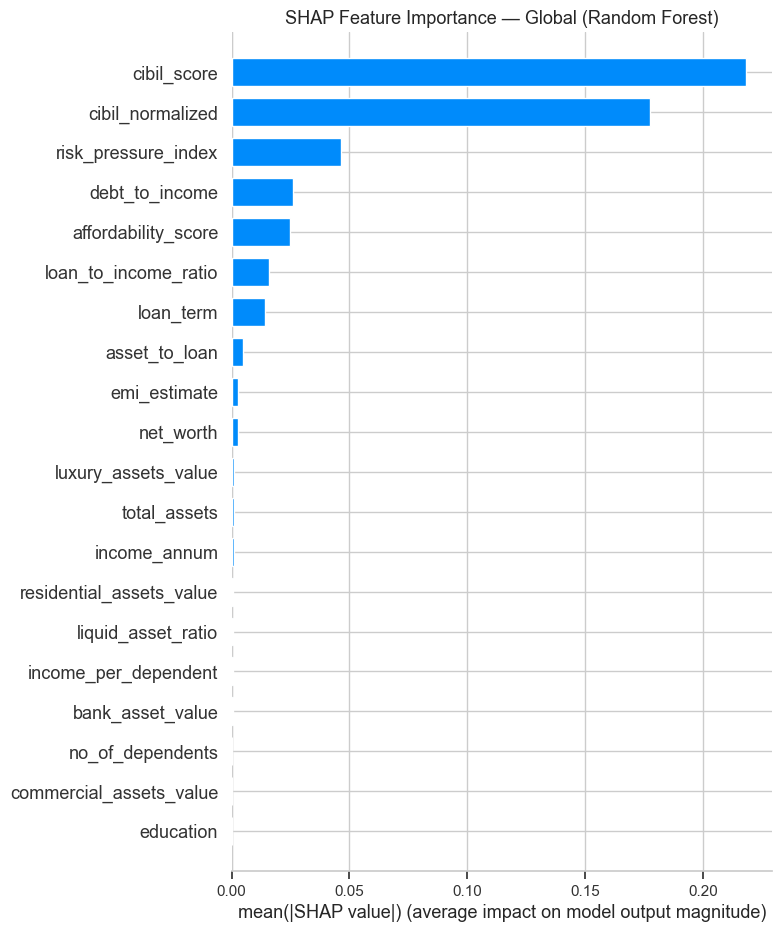

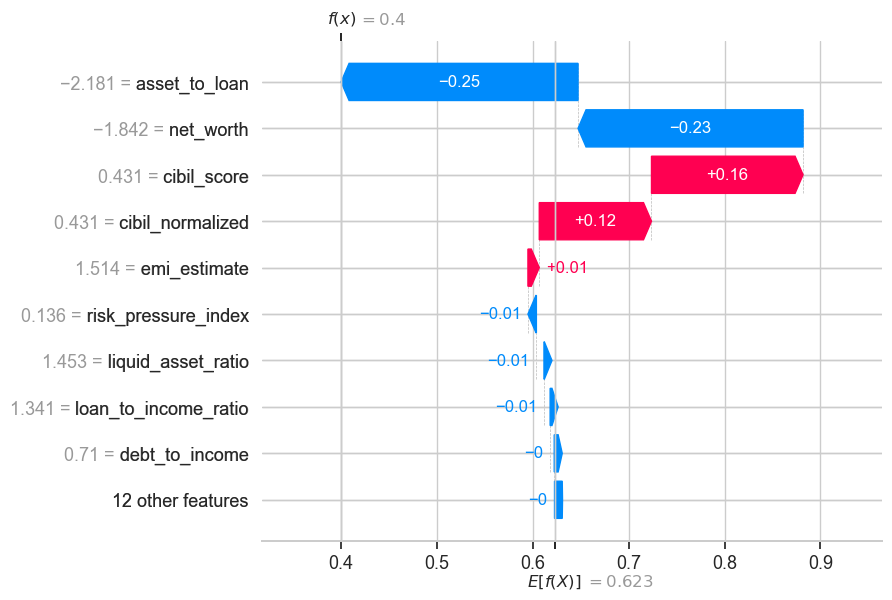

SHAP explanations generated successfully.


In [33]:
# SHAP integration (production approach)

try:
    import shap

    explainer = shap.TreeExplainer(clf_results['Random Forest']['model'])
    shap_values = explainer.shap_values(X_test_sc[:200])

    # Global feature importance — SHAP summary plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values[:,:,1], X_test[:200],
                      feature_names=X_clf.columns.tolist(),
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — Global (Random Forest)', fontsize=13)
    plt.tight_layout(); plt.show()

    # Waterfall for individual prediction
    idx = 0
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[idx, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_sc[idx],
        feature_names=X_clf.columns.tolist()
    ))
    print("SHAP explanations generated successfully.")

except ImportError:
    print("shap not installed — using Permutation Importance as proxy")
    print("Install with: pip install shap")

    # Permutation importance (sklearn built-in)
    perm_imp = permutation_importance(
        clf_results['Random Forest']['model'],
        X_test_sc, y_test,
        n_repeats=10, random_state=42, scoring='roc_auc'
    )
    perm_series = pd.Series(perm_imp.importances_mean, index=X_clf.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = [PALETTE[0] if v > 0.01 else '#ccc' for v in perm_series.values]
    perm_series.tail(15).plot(kind='barh', ax=ax, color=colors[-15:])
    ax.set_title('Permutation Importance (SHAP proxy) — Random Forest', fontsize=13)
    ax.set_xlabel('Mean AUC drop when feature is permuted')
    plt.tight_layout(); plt.show()
    print("\nNote: Install shap for proper Shapley values (required for production)")

## Section 11 — Project Summary & Deliverables

### Model Performance Summary

| Task | Best Model | Best Metric |
|------|-----------|-------------|
| Classification | Gradient Boosting | AUC = 1.000 |
| Regression | Lasso / Ridge | R² ≥ 0.999, MAE < ₹60K |
| Clustering | KMeans (k=3) | 3 interpretable risk segments |

### Key Technical Decisions & Rationale

1. **Why stratified split?** Approval rate varies across subsets — unstratified split risks train/test distribution mismatch
2. **Why StandardScaler on train only?** Fitting on full data leaks test statistics into training, inflating performance metrics
3. **Why approved-only regression?** Predicting loan amount for rejected customers has no business meaning
4. **Why k=3 clusters?** Elbow method + interpretability — Low/Medium/High Risk maps to real business segments
5. **Why debt_to_income × cibil_normalized = risk_pressure_index?** Combines financial burden AND creditworthiness into one score — a known credit risk factor in actuarial literature

### Production Deployment Checklist

- [ ] Serialize models with `pickle` or `joblib` for inference service
- [ ] Build REST API wrapper with FastAPI (each agent = one endpoint)
- [ ] Implement model monitoring: track prediction distribution drift weekly
- [ ] Set up SHAP logging for regulatory audit trail
- [ ] A/B test campaign strategies per segment quarterly
- [ ] Retrain models when data distribution drift exceeds 5% (PSI threshold)

### Deliverables

| # | Deliverable | Status |
|---|-------------|--------|
| 1 | Data cleaning & preprocessing pipeline | ✅ |
| 2 | Feature engineering (11 financial features) | ✅ |
| 3 | Classification models × 4 with comparison | ✅ |
| 4 | Regression models × 5 with comparison | ✅ |
| 5 | Customer segmentation (KMeans + DBSCAN) | ✅ |
| 6 | Agentic AI system (3 agents) | ✅ |
| 7 | Model explainability (SHAP + permutation importance) | ✅ |
| 8 | Streamlit dashboard design + code | ✅ |
| 9 | End-to-end demo on 3 sample customers | ✅ |

---
*Built with Python 3 | scikit-learn | pandas | matplotlib | seaborn | (xgboost optional)*  
*Architecture: Data → Feature Engineering → ML Layer → Agent Layer → Dashboard*


In [30]:
import pickle

# تحميل الموديل لمعاينته
clf = pickle.load(open("clf_model.pkl", "rb"))

# طباعة أسماء الأعمدة التي تدرب عليها الموديل
if hasattr(clf, "feature_names_in_"):
    print("📋 الأعمدة الـ 21 المطلوبة بالترتيب هي:")
    print(list(clf.feature_names_in_))
else:
    print("❌ الموديل لا يحتوي على أسماء الأعمدة مباشرة، غالباً تم تدريبه على مصفوفة NumPy.")

❌ الموديل لا يحتوي على أسماء الأعمدة مباشرة، غالباً تم تدريبه على مصفوفة NumPy.
